Saved runtimes_processed.csv


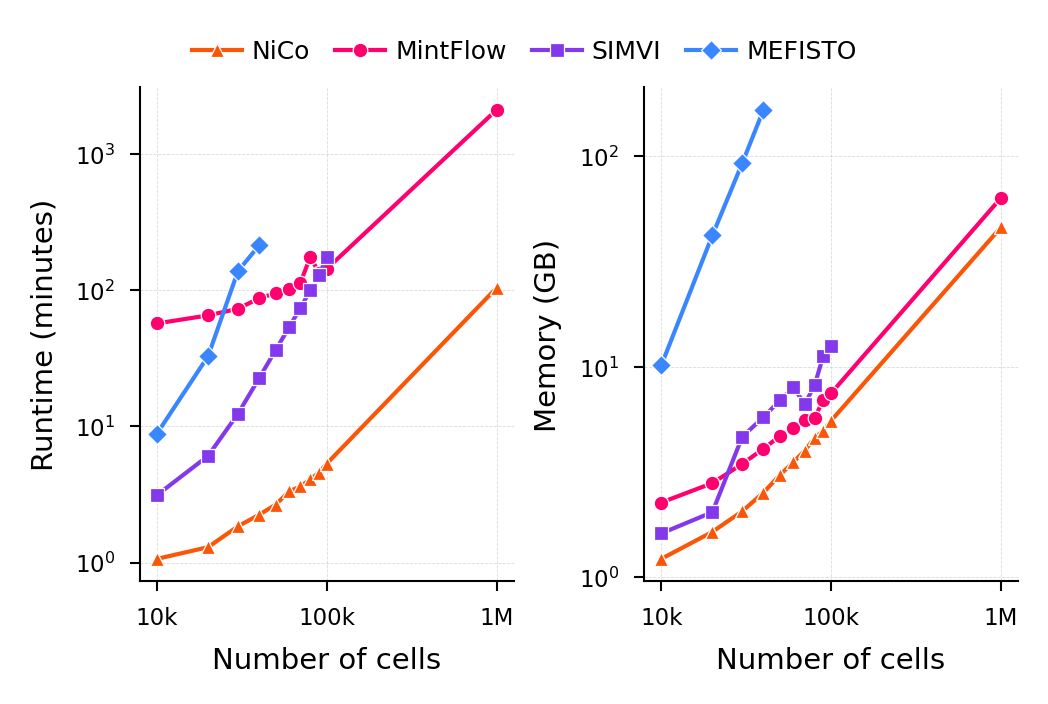

Saved runtime_memory_figure.pdf / .svg / .png


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ── Colours (same as disentanglement plots) ─────────────────────────────
method_rename = {
    "4_MintFlow": "MintFlow",
    "2_SimVI": "SIMVI",
    "3_MEFISTO": "MEFISTO",
    "1_NiCo": "NiCo",
}

method_colors = {
    "MintFlow":  "#FF006E",
    "SIMVI":     "#8338EC",
    "MEFISTO":   "#3A86FF",
    "NiCo":      "#FB5607",
}

method_markers = {
    "MintFlow":  "o",
    "SIMVI":     "s",
    "MEFISTO":   "D",
    "NiCo":      "^",
}

OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/disentanglement"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load data ───────────────────────────────────────────────────────────
df = pd.read_pickle(
    "/nfs/team361/aa36/OnGit/mintflow-benchmarking/Metrics/"
    "1_Disentanglement/3_Actual_Benchmarks/NonGit/ToMakeFigs/"
    "df_timing_and_memory_usage.pkl"
)

df["method"] = df["method"].map(method_rename)
df["runtime_min"] = df["running time (seconds)"] / 60
df["memory_gb"] = df["maximum memory (MB)"] / 1024
df = df.sort_values("number of cells")

# Method order for legend
method_order = ["NiCo", "MintFlow", "SIMVI", "MEFISTO"]

# Save processed CSV
df.to_csv(os.path.join(OUT_DIR, "runtimes_processed.csv"), index=False)
print("Saved runtimes_processed.csv")

# ── Figure: 1×2 panel (Runtime | Memory) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(89 * mm, 55 * mm),
    sharey=False,
)

for method in method_order:
    sub = df[df["method"] == method]
    if sub.empty:
        continue

    x = sub["number of cells"].values
    color = method_colors[method]
    marker = method_markers[method]

    # Runtime
    ax1.plot(
        x, sub["runtime_min"].values,
        color=color, marker=marker, markersize=3.5,
        linewidth=1.0, markeredgecolor="white", markeredgewidth=0.3,
        label=method, zorder=3,
    )

    # Memory
    ax2.plot(
        x, sub["memory_gb"].values,
        color=color, marker=marker, markersize=3.5,
        linewidth=1.0, markeredgecolor="white", markeredgewidth=0.3,
        label=method, zorder=3,
    )

# ── Axes styling ────────────────────────────────────────────────────────
from matplotlib.ticker import LogLocator, NullLocator

for ax in [ax1, ax2]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.yaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.set_axisbelow(True)

    # X-axis: only 10k, 100k, 1M
    ax.set_xticks([1e4, 1e5, 1e6])
    ax.xaxis.set_minor_locator(NullLocator())

    # Y-axis: one tick per decade, no minor ticks
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax.yaxis.set_minor_locator(NullLocator())

    # Format x-axis as "10k", "100k", "1M"
    def format_cells(x, _):
        if x >= 1e6:
            return f"{x/1e6:.0f}M"
        elif x >= 1e3:
            return f"{x/1e3:.0f}k"
        return f"{x:.0f}"
    ax.xaxis.set_major_formatter(FuncFormatter(format_cells))
    ax.set_xlabel("Number of cells", fontweight="medium")

ax1.set_ylabel("Runtime (minutes)", fontweight="medium")
ax2.set_ylabel("Memory (GB)", fontweight="medium")

# Legend — single legend between panels
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=len(method_order),
    fontsize=6,
    frameon=False,
    bbox_to_anchor=(0.5, 1.06),
    columnspacing=1.0,
    handletextpad=0.4,
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.35)

for ext in ["pdf", "svg", "png"]:
    fig.savefig(
        os.path.join(OUT_DIR, f"runtime_memory_figure.{ext}"),
        bbox_inches="tight",
        pad_inches=0.05,
    )
plt.show()
plt.close()
print("Saved runtime_memory_figure.pdf / .svg / .png")